# **1 - Les Importation des Bibliothèques**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.gridspec as gridspec

# **2 - Telechargement de Dataset**

In [ ]:
df=pd.read_csv('/content/social_media_viral_content_dataset.csv')
df.head()

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0
3,SM_100003,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1


# **3 - Comprehension du Dataset**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          2000 non-null   object 
 1   platform         2000 non-null   object 
 2   content_type     2000 non-null   object 
 3   topic            2000 non-null   object 
 4   language         2000 non-null   object 
 5   region           2000 non-null   object 
 6   post_datetime    2000 non-null   object 
 7   hashtags         2000 non-null   object 
 8   views            2000 non-null   int64  
 9   likes            2000 non-null   int64  
 10  comments         2000 non-null   int64  
 11  shares           2000 non-null   int64  
 12  engagement_rate  2000 non-null   float64
 13  sentiment_score  2000 non-null   float64
 14  is_viral         2000 non-null   int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 234.5+ KB


In [ ]:
df.describe()

,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.284860e+06,245329.244000,24786.929000,49936.981500,0.157852,-0.000566,0.699000
std,3.246193e+06,145032.423582,14433.288364,29012.818697,0.535457,0.574911,0.458807
min,4.380000e+03,292.000000,14.000000,127.000000,0.035700,-1.000000,0.000000
25%,1.652742e+06,118903.750000,12337.750000,25698.750000,0.057975,-0.507000,0.000000
50%,3.469408e+06,239831.000000,24519.500000,50212.000000,0.084500,0.001000,1.000000
75%,6.348078e+06,372323.500000,37116.250000,75433.000000,0.142525,0.495250,1.000000
max,1.437179e+07,499983.000000,49989.000000,99977.000000,12.573200,0.999000,1.000000


In [ ]:
df.shape

(2000, 15)

In [ ]:
df.columns

Index(['post_id', 'platform', 'content_type', 'topic', 'language', 'region',
       'post_datetime', 'hashtags', 'views', 'likes', 'comments', 'shares',
       'engagement_rate', 'sentiment_score', 'is_viral'],
      dtype='object')

In [ ]:
print(f"Répartition des publications virales et non virales :\n{df['is_viral'].value_counts().rename_axis(None)}")
print("- - - - - - - - - - - ")
print(f"Distribution des publications par plateforme :\n{df['platform'].value_counts().rename_axis(None)}")
print("- - - - - - - - - - - ")
print(f"Répartition des publications selon le thème (topic) :\n{df['topic'].value_counts().rename_axis(None)}")
print("- - - - - - - - - - - ")
print(f"Répartition des publications par type de contenu :\n{df['content_type'].value_counts().rename_axis(None)}")
print("- - - - - - - - - - - ")
print(f"Distribution des publications par région :\n{df['region'].value_counts().rename_axis(None)}")
print("- - - - - - - - - - - ")
print(f"Distribution des publications par langue :\n{df['language'].value_counts().rename_axis(None)}")

Répartition des publications virales et non virales :
1    1398
0     602
Name: count, dtype: int64
- - - - - - - - - - - 
Distribution des publications par plateforme :
Instagram         539
YouTube Shorts    499
X                 485
TikTok            477
Name: count, dtype: int64
- - - - - - - - - - - 
Répartition des publications selon le thème (topic) :
Education        347
Entertainment    345
Politics         332
Technology       331
Sports           330
Lifestyle        315
Name: count, dtype: int64
- - - - - - - - - - - 
Répartition des publications par type de contenu :
carousel    528
image       512
text        488
video       472
Name: count, dtype: int64
- - - - - - - - - - - 
Distribution des publications par région :
US          428
India       406
Brazil      402
UK          385
Pakistan    379
Name: count, dtype: int64
- - - - - - - - - - - 
Distribution des publications par langue :
en    420
ur    405
fr    404
hi    392
es    379
Name: count, dtype: int64


# **4 - Nettoyage des Valeurs Nulls**

In [ ]:
df.isnull().sum()

,0
post_id,0
platform,0
content_type,0
topic,0
language,0
region,0
post_datetime,0
hashtags,0
views,0
likes,0


In [ ]:
(df==0).sum()

,0
post_id,0
platform,0
content_type,0
topic,0
language,0
region,0
post_datetime,0
hashtags,0
views,0
likes,0


In [ ]:
df = df.dropna()
print(f"Dataset après suppression des nulls : {df.shape}")

Dataset après suppression des nulls : (2000, 15)


# **5 - Nettoyage outliers**

In [ ]:
Q1  = df['engagement_rate'].quantile(0.25)
Q3  = df['engagement_rate'].quantile(0.75)
IQR = Q3 - Q1

In [ ]:
df_clean = df[
    (df['engagement_rate'] >= Q1 - 1.5 * IQR) &
    (df['engagement_rate'] <= Q3 + 1.5 * IQR)].copy()

In [ ]:
print(f"Lignes avant nettoyage : {len(df)}")
print(f"Outliers supprimés     : {len(df) - len(df_clean)}")
print(f"Lignes après nettoyage : {len(df_clean)}")

Lignes avant nettoyage : 2000
Outliers supprimés     : 128
Lignes après nettoyage : 1872


# **6 - Feature Engineering**

In [ ]:
df_clean['engagement_total'] = df_clean['likes'] + df_clean['comments'] + df_clean['shares']

In [ ]:
df_clean['post_datetime'] = pd.to_datetime(df_clean['post_datetime'])

In [ ]:
df_clean['month'] = df_clean['post_datetime'].dt.month

In [ ]:
df_clean['month_name'] = df_clean['post_datetime'].dt.strftime('%B')

In [ ]:
df_clean['day_of_week'] = df_clean['post_datetime'].dt.dayofweek

In [ ]:
df_clean['day_name'] = df_clean['post_datetime'].dt.strftime('%A')

In [ ]:
df_clean['quarter'] = df_clean['post_datetime'].dt.quarter

In [ ]:
df_clean.head()

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,...,shares,engagement_rate,sentiment_score,is_viral,engagement_total,month,month_name,day_of_week,day_name,quarter
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10,#tech #funny #music,2319102,122058,...,861,0.0598,0.464,1,138719,12,December,1,Tuesday,4
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13,#news #fyp #funny #ai #trending,2538464,110368,...,54887,0.0695,-0.800,1,176544,10,October,6,Sunday,4
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03,#ai #news,1051176,87598,...,44132,0.1702,0.416,0,178926,5,May,4,Friday,2
3,SM_100003,X,text,Politics,ur,US,2024-08-04,#ai #funny,5271440,329465,...,59736,0.0740,0.877,1,389975,8,August,6,Sunday,3
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28,#news #ai #viral #funny #fyp,3186256,199141,...,83105,0.0903,0.223,1,287562,3,March,3,Thursday,1


# **7 - Analyse Exploratoire - EDA**

/tmp/ipykernel_10826/2566726907.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(data_box, labels=content_types, patch_artist=True)
/tmp/ipykernel_10826/2566726907.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


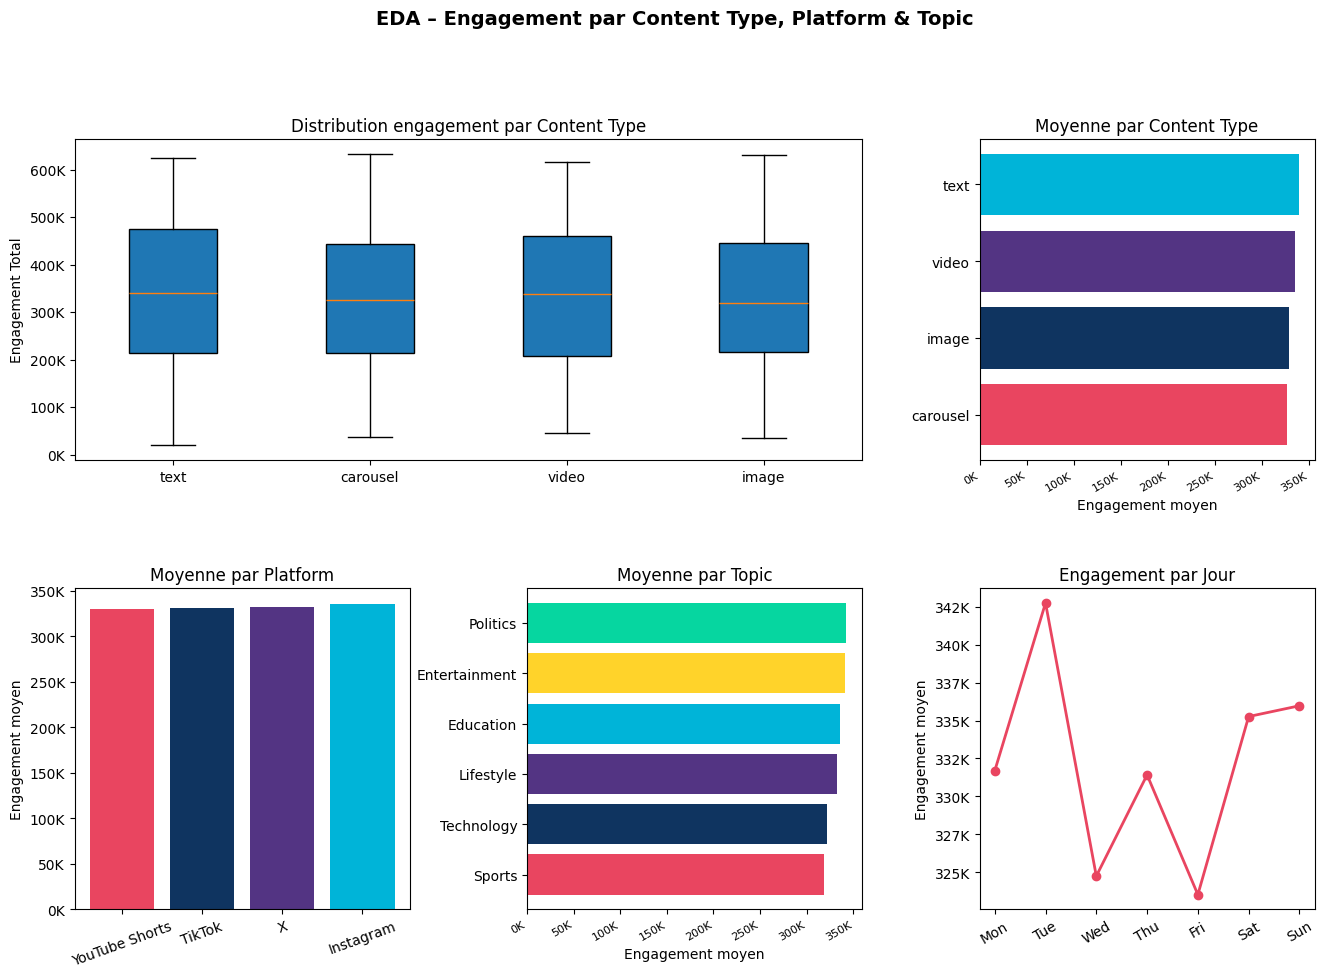

In [ ]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('EDA – Engagement par Content Type, Platform & Topic',
             fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Graphe 1 : Boxplot par content_type
ax1 = fig.add_subplot(gs[0, :2])
content_types = df_clean['content_type'].unique()
data_box = [df_clean[df_clean['content_type'] == ct]['engagement_total'].values
            for ct in content_types]
ax1.boxplot(data_box, labels=content_types, patch_artist=True)
ax1.set_title('Distribution engagement par Content Type')
ax1.set_ylabel('Engagement Total')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

# Graphe 2 : Moyenne par content_type
ax2 = fig.add_subplot(gs[0, 2])
means = df_clean.groupby('content_type')['engagement_total'].mean().sort_values()
ax2.barh(means.index, means.values, color=['#e94560','#0f3460','#533483','#00b4d8'])
ax2.set_title('Moyenne par Content Type')
ax2.set_xlabel('Engagement moyen')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# Graphe 3 : Moyenne par platform
ax3 = fig.add_subplot(gs[1, 0])
plat = df_clean.groupby('platform')['engagement_total'].mean().sort_values()
ax3.bar(plat.index, plat.values, color=['#e94560','#0f3460','#533483','#00b4d8'])
ax3.set_title('Moyenne par Platform')
ax3.set_ylabel('Engagement moyen')
ax3.tick_params(axis='x', rotation=20)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

# Graphe 4 : Moyenne par topic
ax4 = fig.add_subplot(gs[1, 1])
topic = df_clean.groupby('topic')['engagement_total'].mean().sort_values()
ax4.barh(topic.index, topic.values,
         color=['#e94560','#0f3460','#533483','#00b4d8','#ffd32a','#06d6a0'])
ax4.set_title('Moyenne par Topic')
ax4.set_xlabel('Engagement moyen')
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.setp(ax4.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# Graphe 5 : Engagement par jour
ax5 = fig.add_subplot(gs[1, 2])
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_means = df_clean.groupby('day_name')['engagement_total'].mean().reindex(day_order)
ax5.plot(range(7), day_means.values, marker='o', color='#e94560', linewidth=2)
ax5.set_xticks(range(7))
ax5.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=30)
ax5.set_title('Engagement par Jour')
ax5.set_ylabel('Engagement moyen')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.tight_layout()
plt.show()

# **8 - Hypothèses H0/H1**

In [ ]:
print("=" * 50)
print("HYPOTHÈSES")
print("=" * 50)
print("H0 : Le type de contenu n'influence PAS l'engagement")
print("H1 : Le type de contenu influence significativement l'engagement")
print("Seuil : α = 0.05")
print("=" * 50)

HYPOTHÈSES
H0 : Le type de contenu n'influence PAS l'engagement
H1 : Le type de contenu influence significativement l'engagement
Seuil : α = 0.05


# **9 - Test ANOVA**

In [ ]:
from scipy import stats

In [ ]:
carousel = df_clean[df_clean['content_type'] == 'carousel']['engagement_total']
image = df_clean[df_clean['content_type'] == 'image']['engagement_total']
text = df_clean[df_clean['content_type'] == 'text']['engagement_total']
video = df_clean[df_clean['content_type'] == 'video']['engagement_total']

In [ ]:
f_stat, p_value = stats.f_oneway(carousel, image, text, video)

In [ ]:
print(f"F-statistique : {f_stat:.4f}")
print(f"P-value       : {p_value:.4f}")
print()
if p_value < 0.05:
    print("On rejette H0")
    print("Il existe une différence significative entre les types de contenu")
else:
    print("On ne rejette pas H0")
    print("Pas de différence significative entre les types de contenu")

F-statistique : 0.7973
P-value       : 0.4953

On ne rejette pas H0
Pas de différence significative entre les types de contenu


# **10 - Test Tukey + Visualisation**

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(
    endog=df_clean['engagement_total'],
    groups=df_clean['content_type'],
    alpha=0.05)

In [ ]:
print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
 group1  group2  meandiff  p-adj     lower      upper    reject
---------------------------------------------------------------
carousel  image  2303.4368 0.9946 -21452.5245 26059.3981  False
carousel   text 12860.3586 0.5137 -11147.6422 36868.3593  False
carousel  video  8902.0993  0.778 -15203.4332 33007.6319  False
   image   text 10556.9218 0.6779 -13704.4571 34818.3006  False
   image  video  6598.6625 0.8984 -17759.2336 30956.5586  False
    text  video -3958.2592 0.9761 -28562.0294 20645.5109  False
---------------------------------------------------------------


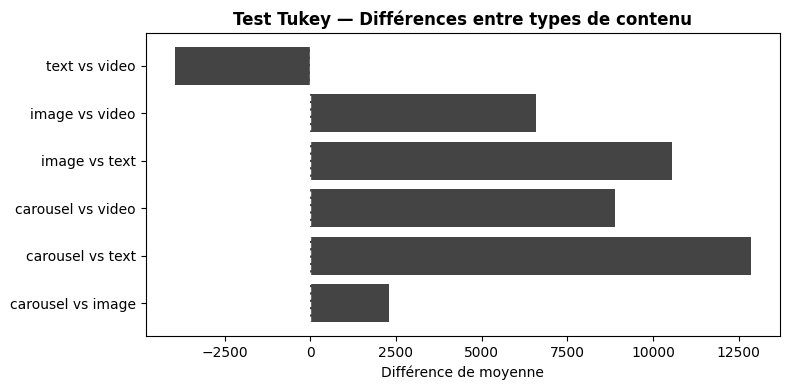

In [ ]:
tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0])
tukey_df['comparaison'] = tukey_df['group1'] + ' vs ' + tukey_df['group2']
tukey_df['reject']      = tukey_df['reject'].astype(bool)

colors_bar = ['#e94560' if r else '#444444' for r in tukey_df['reject']]
plt.figure(figsize=(8, 4))
plt.barh(tukey_df['comparaison'], tukey_df['meandiff'].astype(float), color=colors_bar)
plt.axvline(0, color='white', linewidth=1, linestyle='--')
plt.title('Test Tukey — Différences entre types de contenu', fontweight='bold')
plt.xlabel('Différence de moyenne')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10826/2021844367.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


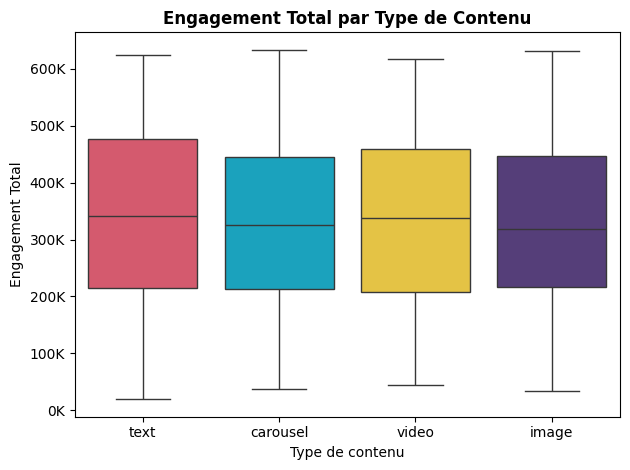

In [ ]:
sns.boxplot(
    x='content_type',
    y='engagement_total',
    data=df_clean,
    palette=['#e94560','#00b4d8','#ffd32a','#533483'])
plt.title('Engagement Total par Type de Contenu', fontweight='bold')
plt.xlabel('Type de contenu')
plt.ylabel('Engagement Total')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.tight_layout()
plt.show()

# **11 - Conclusion**

In [ ]:
best_type  = df_clean.groupby('content_type')['engagement_total'].mean().idxmax()
best_plat  = df_clean.groupby('platform')['engagement_total'].mean().idxmax()
best_topic = df_clean.groupby('topic')['engagement_total'].mean().idxmax()
best_day   = df_clean.groupby('day_name')['engagement_total'].mean().idxmax()

print("=" * 50)
print("CONCLUSION DU PROJET")
print("=" * 50)
print(f"\n• F-statistique : {f_stat:.4f}")
print(f"• P-value       : {p_value:.4f}\n")
print(f" Meilleur type de contenu : {best_type}")
print(f" Meilleure plateforme     : {best_plat}")
print(f" Meilleur topic           : {best_topic}")
print(f" Meilleur jour            : {best_day}")
print()
print("RECOMMANDATIONS :")
print(f"  → Publier du contenu '{best_type}' sur '{best_plat}'")
print(f"  → Choisir le topic '{best_topic}'")
print(f"  → Publier le '{best_day}' pour maximiser l'engagement")

CONCLUSION DU PROJET

• F-statistique : 0.7973
• P-value       : 0.4953

 Meilleur type de contenu : text
 Meilleure plateforme     : Instagram
 Meilleur topic           : Politics
 Meilleur jour            : Tuesday

RECOMMANDATIONS :
  → Publier du contenu 'text' sur 'Instagram'
  → Choisir le topic 'Politics'
  → Publier le 'Tuesday' pour maximiser l'engagement
